# Modeling after Feature Cleaning

In [1]:
# ==========
# 0. 패키지
# ==========

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
from sklearn.impute import SimpleImputer

In [2]:
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 150)

In [3]:
# ===============
# 1. 데이터 로드
# ===============
DATA_DIR = Path('../Data')
train = pd.read_csv(DATA_DIR / "train_cleaning.csv")
test  = pd.read_csv(DATA_DIR / "test_cleaning.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

TARGET = "fraud"

X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()
X_test = test.copy()

print("Fraud rate:", y.mean())

train shape: (18000, 126)
test shape : (12000, 125)
Fraud rate: 0.1582222222222222


In [4]:
# ===========
# 2. CV 설정
# ===========
N_SPLITS = 5
RANDOM_STATE = 2542

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [5]:
# ==================================
# 3. LightGBM 파라미터
# ----------------------------------
# Modeling_V4와 동일한 파라미터 사용
# ==================================
pos = (y == 1).sum()
neg = (y == 0).sum()
scale_pos_weight = (neg / pos) * 1.1

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.5,
    "n_estimators": 10000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "verbosity": -1,
}

In [6]:
# ===================
# 4. Fold 반복 학습
# ===================
# 결과 저장 변수
oof_pred = np.zeros(len(X))
oof_pred_label = np.zeros(len(X), dtype=int)
test_pred = np.zeros(len(X_test))

fold_scores = []
feature_importance_list = []
models = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*20} Fold {fold} {'='*20}")

    X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
    y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()

    # 클래스 불균형 반영
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = lgb.LGBMClassifier(**params)

    fit_kwargs = dict(
        X=X_train,
        y=y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=300),
            lgb.log_evaluation(period=200)
        ]
    )

    model.fit(**fit_kwargs)

    # validation prediction
    threshold = 0.4
    valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    valid_pred_label = (valid_pred_proba >= threshold).astype(int)

    # OOF 저장
    oof_pred[valid_idx] = valid_pred_proba
    oof_pred_label[valid_idx] = valid_pred_label

    # test prediction 저장
    test_pred += model.predict_proba(X_test)[:, 1] / N_SPLITS

    # fold metric
    fold_auc    = roc_auc_score(y_valid, valid_pred_proba)
    fold_pr_auc = average_precision_score(y_valid, valid_pred_proba)
    fold_f1     = f1_score(y_valid, valid_pred_label, zero_division=0)

    print(f"Fold {fold} ROC-AUC : {fold_auc:.4f}")
    print(f"Fold {fold} PR-AUC  : {fold_pr_auc:.4f}")
    print(f"Fold {fold} F1      : {fold_f1:.4f}")

    fold_scores.append({
        "fold":    fold,
        "roc_auc": fold_auc,
        "pr_auc":  fold_pr_auc,
        "f1":      fold_f1
    })

    # feature importance 저장
    fold_importance = pd.DataFrame({
        "feature":    X.columns,
        "importance": model.feature_importances_,
        "fold":       fold
    })
    feature_importance_list.append(fold_importance)

    models.append(model)


==================== Fold 1 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.676409
[400]	valid_0's auc: 0.670402
Early stopping, best iteration is:
[136]	valid_0's auc: 0.679023
Fold 1 ROC-AUC : 0.6790
Fold 1 PR-AUC  : 0.2762
Fold 1 F1      : 0.3417

==================== Fold 2 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.701733
Early stopping, best iteration is:
[84]	valid_0's auc: 0.707465
Fold 2 ROC-AUC : 0.7075
Fold 2 PR-AUC  : 0.3083
Fold 2 F1      : 0.3514

==================== Fold 3 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.68361
Early stopping, best iteration is:
[53]	valid_0's auc: 0.688367
Fold 3 ROC-AUC : 0.6884
Fold 3 PR-AUC  : 0.2685
Fold 3 F1      : 0.3544

==================== Fold 4 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.6

In [7]:
# ===================
# 5. Fold 결과 요약
# ===================
score_df = pd.DataFrame(fold_scores)

print("\n========== Fold Scores ==========")
print(score_df)

print("\n========== CV Mean Scores ==========")
print(f"Mean ROC-AUC : {score_df['roc_auc'].mean():.4f}")
print(f"Std  ROC-AUC : {score_df['roc_auc'].std():.4f}")
print(f"Mean PR-AUC  : {score_df['pr_auc'].mean():.4f}")
print(f"Mean F1      : {score_df['f1'].mean():.4f}")


========== Fold Scores ==========
   fold   roc_auc    pr_auc        f1
0     1  0.679023  0.276236  0.341678
1     2  0.707465  0.308342  0.351410
2     3  0.688367  0.268503  0.354396
3     4  0.688681  0.292428  0.343685
4     5  0.704063  0.286392  0.361738

========== CV Mean Scores ==========
Mean ROC-AUC : 0.6935
Std  ROC-AUC : 0.0119
Mean PR-AUC  : 0.2864
Mean F1      : 0.3506


In [8]:
# ===========================
# 6. 전체 OOF 기준 성능 평가
# ===========================
oof_auc    = roc_auc_score(y, oof_pred)
oof_pr_auc = average_precision_score(y, oof_pred)
oof_f1     = f1_score(y, oof_pred_label, zero_division=0)

print("\n========== OOF Overall Performance ==========")
print(f"OOF ROC-AUC : {oof_auc:.4f}")
print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")
print(f"OOF F1      : {oof_f1:.4f}")

print("\n========== OOF Confusion Matrix ==========")
print(confusion_matrix(y, oof_pred_label))

print("\n========== OOF Classification Report ==========")
print(classification_report(y, oof_pred_label, digits=4, zero_division=0))


========== OOF Overall Performance ==========
OOF ROC-AUC : 0.6921
OOF PR-AUC  : 0.2820
OOF F1      : 0.3506

========== OOF Confusion Matrix ==========
[[8454 6698]
 [ 819 2029]]

========== OOF Classification Report ==========
              precision    recall  f1-score   support

         0.0     0.9117    0.5579    0.6922     15152
         1.0     0.2325    0.7124    0.3506      2848

    accuracy                         0.5824     18000
   macro avg     0.5721    0.6352    0.5214     18000
weighted avg     0.8042    0.5824    0.6382     18000



In [9]:
# ===========================
# 7. 평균 Feature Importance
# ===========================
importance_df = pd.concat(feature_importance_list, axis=0)

mean_importance = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n========== Mean Feature Importance (Top 30) ==========")
print(mean_importance.head(30))


========== Mean Feature Importance (Top 30) ==========
                           feature  importance
0     age_of_driver_x_safty_rating       231.6
1                  age_over_safety       206.2
2                    age_of_driver       204.4
3               zip_fraud_rate_oof       181.2
4                   vehicle_weight       176.0
5        income_safety_interaction       172.0
6                    annual_income       165.0
7                 price_per_weight       161.8
8         zip_rate_x_annual_income       159.8
9   age_of_driver_x_vehicle_weight       156.2
10        safty_rating_x_liab_prct       154.2
11                       claim_day       152.0
12        residual_to_income_ratio       144.0
13        composite_x_income_ratio       143.8
14      vehicle_weight_x_liab_prct       136.6
15    vehicle_price_per_driver_age       134.0
16       annual_income_x_liab_prct       130.8
17                    safty_rating       129.2
18         vehicle_to_income_ratio       124.6
19  

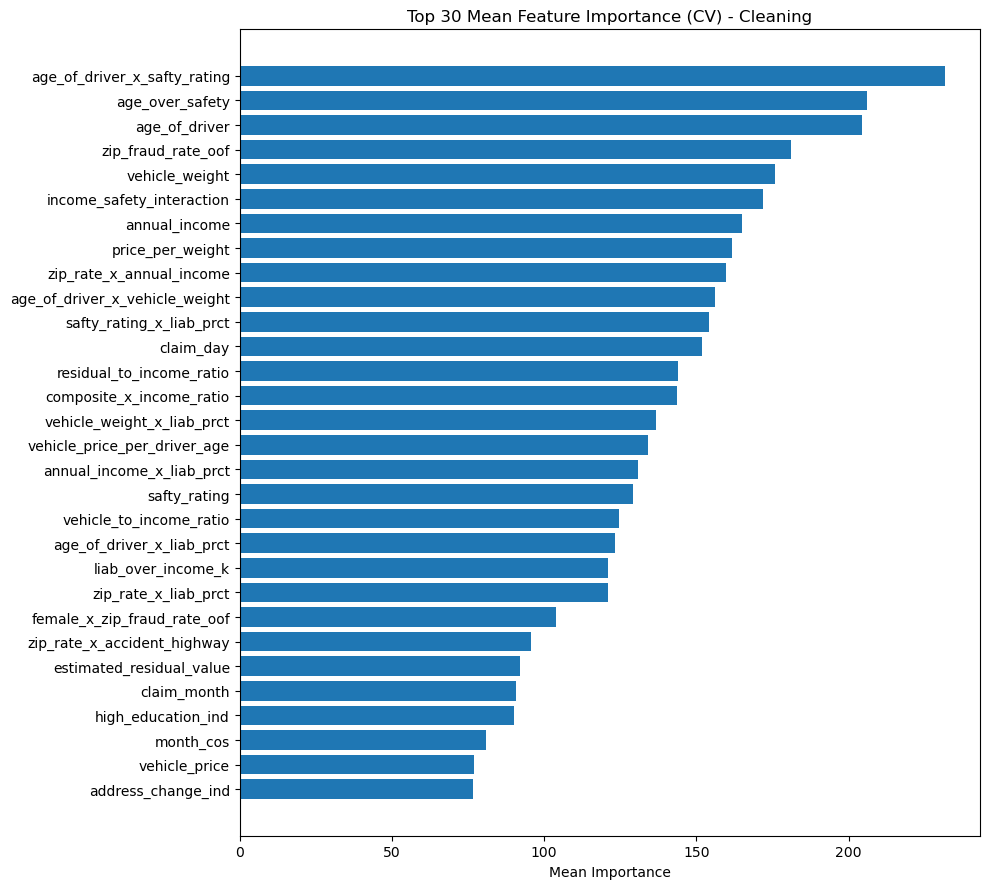

In [10]:
# =============================
# 8. Feature Importance 시각화
# =============================
top_k = 30

plt.figure(figsize=(10, 9))
plt.barh(
    mean_importance["feature"].head(top_k)[::-1],
    mean_importance["importance"].head(top_k)[::-1]
)
plt.title("Top 30 Mean Feature Importance (CV) - Cleaning")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [11]:
# ====================
# 9. Recall@TopK 함수
# ====================
def recall_at_k(y_true, pred_prob, k_ratio=0.1):
    k = int(len(pred_prob) * k_ratio)
    top_idx = np.argsort(pred_prob)[::-1][:k]
    recall = y_true.iloc[top_idx].sum() / y_true.sum()
    return recall

In [12]:
# =====================
# 10. Recall@TopK 출력
# =====================
k_list = [0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

print("\n========== Recall@TopK ==========")
for k in k_list:
    recall_k = recall_at_k(y, oof_pred, k_ratio=k)
    print(f"Recall@Top{int(k*100)}%: {recall_k:.4f}")


========== Recall@TopK ==========
Recall@Top1%: 0.0249
Recall@Top3%: 0.0758
Recall@Top5%: 0.1222
Recall@Top10%: 0.2121
Recall@Top20%: 0.3739
Recall@Top30%: 0.5130


In [13]:
# =====================
# 11. Threshold Tuning
# =====================
threshold_list = np.arange(0.05, 0.51, 0.05)

result_list = []

print("========== Threshold Tuning ==========")

for th in threshold_list:
    pred_label = (oof_pred >= th).astype(int)

    f1        = f1_score(y, pred_label, zero_division=0)
    precision = precision_score(y, pred_label, zero_division=0)
    recall    = recall_score(y, pred_label, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y, pred_label).ravel()

    result_list.append({
        "threshold": th,
        "f1":        f1,
        "precision": precision,
        "recall":    recall,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn
    })

    print(f"\nThreshold = {th:.2f}")
    print(f"F1        : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")

result_df = pd.DataFrame(result_list)

========== Threshold Tuning ==========

Threshold = 0.05
F1        : 0.2756
Precision : 0.1599
Recall    : 0.9996
TP=2847 FP=14962 FN=1 TN=190

Threshold = 0.10
F1        : 0.2862
Precision : 0.1671
Recall    : 0.9958
TP=2836 FP=14132 FN=12 TN=1020

Threshold = 0.15
F1        : 0.2975
Precision : 0.1753
Recall    : 0.9824
TP=2798 FP=13164 FN=50 TN=1988

Threshold = 0.20
F1        : 0.3087
Precision : 0.1840
Recall    : 0.9575
TP=2727 FP=12090 FN=121 TN=3062

Threshold = 0.25
F1        : 0.3197
Precision : 0.1936
Recall    : 0.9164
TP=2610 FP=10869 FN=238 TN=4283

Threshold = 0.30
F1        : 0.3329
Precision : 0.2060
Recall    : 0.8673
TP=2470 FP=9522 FN=378 TN=5630

Threshold = 0.35
F1        : 0.3439
Precision : 0.2192
Recall    : 0.7988
TP=2275 FP=8106 FN=573 TN=7046

Threshold = 0.40
F1        : 0.3506
Precision : 0.2325
Recall    : 0.7124
TP=2029 FP=6698 FN=819 TN=8454

Threshold = 0.45
F1        : 0.3560
Precision : 0.2503
Recall    : 0.6162
TP=1755 FP=5256 FN=1093 TN=9896

Thres

In [14]:
# ===================
# 12. Best Threshold
# ===================
best_idx = result_df['f1'].idxmax()
print("\n========== Best Threshold ==========")
print(result_df.loc[best_idx])


========== Best Threshold ==========
threshold       0.450000
f1              0.356020
precision       0.250321
recall          0.616222
tp           1755.000000
fp           5256.000000
fn           1093.000000
tn           9896.000000
Name: 8, dtype: float64


In [15]:
# ======================
# 13. V4 대비 성능 비교
# ======================
print("\n========== 성능 비교 (V4 vs Cleaning) ==========")
print(f"{'':30s} {'V4':>10s} {'Cleaning':>10s}")
print(f"{'ROC-AUC (OOF)':30s} {'0.6908':>10s} {oof_auc:>10.4f}")
print(f"{'Recall@Top10%':30s} {'0.2177':>10s} {recall_at_k(y, oof_pred, 0.10):>10.4f}")
print(f"{'PR-AUC':30s} {'0.2767':>10s} {oof_pr_auc:>10.4f}")


========== 성능 비교 (V4 vs Cleaning) ==========
                                       V4   Cleaning
ROC-AUC (OOF)                      0.6908     0.6921
Recall@Top10%                      0.2177     0.2121
PR-AUC                             0.2767     0.2820


- ROC-AUC와 PR-AUC는 소폭 개선
- cleaning 데이터셋으로 고정 후, 모델 비교 진행